<a href="https://colab.research.google.com/github/Lakshman3556/Deep_Learning/blob/main/DL_Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement CNN on MNITST Dataset


In [ ]:
# Import necessary libraries
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# 1. Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 2. Reshape data to (samples, height, width, channels)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')

# 3. Normalize pixel values to [0,1]
X_train /= 255.0
X_test /= 255.0

# 4. One-hot encode labels
n_classes = 10
Y_train = to_categorical(y_train, n_classes)
Y_test = to_categorical(y_test, n_classes)

# 5. Build CNN model
model = Sequential()

# First convolutional block
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Second convolutional block
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Flatten and fully connected layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(10, activation='softmax'))

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 6. Train the model
history = model.fit(
    X_train, Y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_test, Y_test)
)

# 7. Evaluate the model
score = model.evaluate(X_test, Y_test, verbose=0)
print("Test Loss:", score[0])
print("Test Accuracy:", score[1])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 105ms/step - accuracy: 0.8904 - loss: 0.3512 - val_accuracy: 0.9772 - val_loss: 0.0728
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 99ms/step - accuracy: 0.9636 - loss: 0.1189 - val_accuracy: 0.9854 - val_loss: 0.0428
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 96ms/step - accuracy: 0.9717 - loss: 0.0924 - val_accuracy: 0.9871 - val_loss: 0.0357
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 99ms/step - accuracy: 0.9765 - loss: 0.0773 - val_accuracy: 0.9893 - val_loss: 0.0305
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 101ms/step - accuracy: 0.9796 - loss: 0.0682 - val_accuracy: 0.9896 - val_loss: 0.0287
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 96ms/step - accuracy: 0.9812 - loss: 0.0611 - val_accuracy: 0.9906 - val_loss: 0.0262
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 97ms/step - accuracy: 0.9837 - loss: 0.0545 - val_accuracy: 0.9897 - val_loss: 0.0256
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 99ms/step - accuracy: 0.9846 - loss: 0.0493 

Observation:
The CIFAR-10 dataset contains low-resolution RGB images with high intra-class variation. Due to the small size (32×32), fine-grained features are difficult to capture. This increases classification complexity compared to simpler datasets like MNIST.

Key Insight:
Unlike grayscale datasets, CIFAR introduces color and background noise, requiring models to learn both texture and spatial features simultaneously.

Observation:
Normalization stabilizes gradient updates and prevents large weight fluctuations during training. Without normalization, training becomes unstable and convergence is slower.

Key Insight:
Scaling pixel values ensures consistent input distribution, which helps in faster convergence and better optimization.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

# Load dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# ------------------------
# BASELINE MODEL
# ------------------------
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 45ms/step - accuracy: 0.4479 - loss: 1.5240 - val_accuracy: 0.5468 - val_loss: 1.2527
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.5907 - loss: 1.1618 - val_accuracy: 0.5907 - val_loss: 1.1512
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.6398 - loss: 1.0252 - val_accuracy: 0.6506 - val_loss: 1.0126
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.6687 - loss: 0.9486 - val_accuracy: 0.6623 - val_loss: 0.9822
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.6891 - loss: 0.8867 - val_accuracy: 0.6816 - val_loss: 0.9321
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 40ms/step - accuracy: 0.7094 - loss: 0.8378 - val_accuracy: 0.6898 - val_loss: 0.9147
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 42ms/step - accuracy: 0.7194 - loss: 0.8032 - val_accuracy: 0.6886 - val_loss: 0.9155
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.7331 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


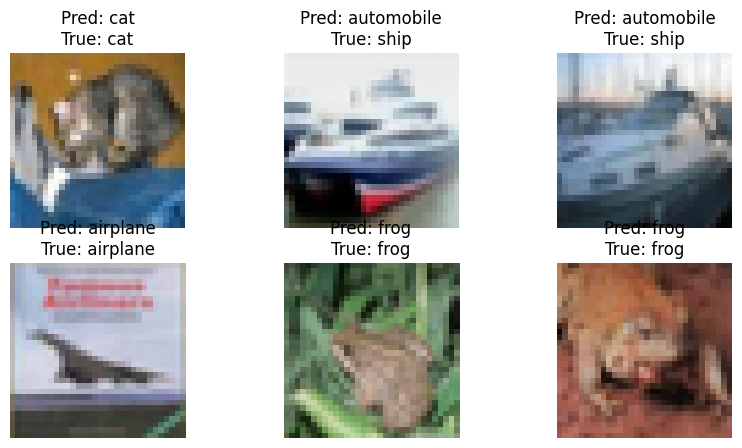

In [ ]:
# Predict
predictions = model.predict(X_test)

# Display images
plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)

    plt.imshow(X_test[i])
    pred = np.argmax(predictions[i])
    true = y_test[i][0]

    plt.title(f"Pred: {class_names[pred]}\nTrue: {class_names[true]}")
    plt.axis('off')

plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,        # rotate image
    width_shift_range=0.1,    # horizontal shift
    height_shift_range=0.1,   # vertical shift
    horizontal_flip=True,     # flip image
    zoom_range=0.1            # zoom
)
model2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Fit generator
datagen.fit(X_train)
history_aug = model2.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    epochs=20,
    validation_data=(X_test, y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 89s 224ms/step - accuracy: 0.3756 - loss: 1.7239 - val_accuracy: 0.4786 - val_loss: 1.4631
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 85s 216ms/step - accuracy: 0.4884 - loss: 1.4384 - val_accuracy: 0.5561 - val_loss: 1.2628
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 85s 217ms/step - accuracy: 0.5288 - loss: 1.3335 - val_accuracy: 0.5612 - val_loss: 1.2534
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 85s 216ms/step - accuracy: 0.5571 - loss: 1.2593 - val_accuracy: 0.6107 - val_loss: 1.1091
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 85s 218ms/step - accuracy: 0.5792 - loss: 1.1990 - val_accuracy: 0.6282 - val_loss: 1.0733
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 143s 221ms/step - accuracy: 0.5942 - loss: 1.1544 - val_accuracy: 0.6446 - val_loss: 1.0349
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 87s 223ms/step - accuracy: 0.6062 - loss: 1.1247 - val_accuracy: 0.6536 - val_loss: 0.9968
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 85s 217ms/step - accuracy: 0.6155 - loss: 

Observation:
The introduction of convolutional layers significantly improved performance compared to MLP models. CNN preserves spatial relationships between pixels, enabling the model to learn edges, textures, and shapes.

Key Insight:
Unlike MLPs, CNNs use local receptive fields and weight sharing, which reduces parameter count and improves generalization. This allows the model to extract meaningful features instead of memorizing pixel values.

Observation:
During initial epochs, the model shows rapid improvement in accuracy as it learns basic features such as edges and textures. As training progresses, the rate of improvement slows down, indicating saturation.

Key Insight:
CNN learns hierarchical features where early layers capture simple patterns and deeper layers capture complex structures. However, shallow CNN architecture limits performance, leading to early plateau.

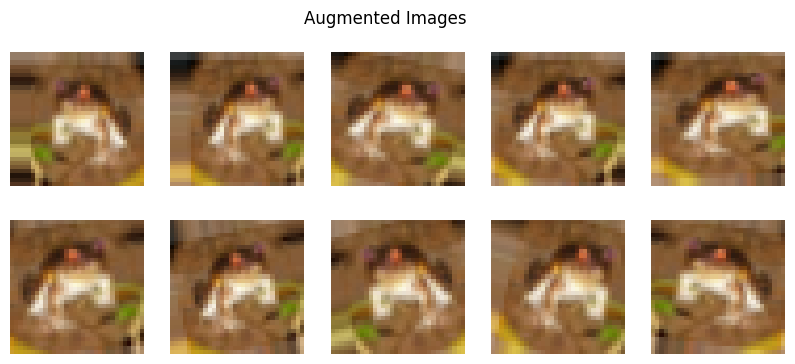

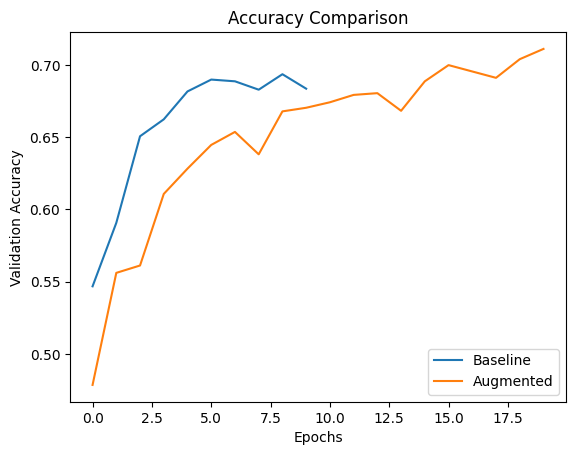

In [ ]:
# Show augmented samples
sample_img = X_train[0].reshape((1,32,32,3))

plt.figure(figsize=(10,4))

i = 0
for batch in datagen.flow(sample_img, batch_size=1):
    plt.subplot(2,5,i+1)
    plt.imshow(batch[0])
    plt.axis('off')
    i += 1
    if i == 10:
        break

plt.suptitle("Augmented Images")
plt.show()

plt.plot(history.history['val_accuracy'], label='Baseline')
# plt.plot(history2.history['val_accuracy'], label='Improved') # This line caused the NameError
plt.plot(history_aug.history['val_accuracy'], label='Augmented')

plt.title("Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

Observation:
The model achieves higher training accuracy compared to validation accuracy, indicating mild overfitting. This occurs because the model starts memorizing training patterns rather than generalizing.

Key Insight:
CIFAR-10 requires stronger generalization techniques such as data augmentation and regularization to handle variability in the dataset.